In [1]:
import pandas as pd 
import numpy as np
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import re
from collections import Counter
from sklearn.decomposition import TruncatedSVD
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from src.data import *
from src.features import *
from src.models import *


c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data loading and preprocessing

When creating samples list, we encountered parsing errors due to unescaped apostrophes in entity names. For example, `{'Sebi': 'neutral', 'Osian's Art Fund': 'neutral'}` is invalid because the apostrophe in *Osian's* prematurely closes the string, causing `ast.literal_eval` to fail. We fixed this with a preprocessing step where we handle errors one by one.

In [2]:
df = pd.read_csv("SEntFiN.csv", index_col=False)
df_ent = pd.read_csv("entity_list_comprehensive.csv", index_col=False)

In [3]:
samples = create_clean_sample_map(df, df_ent)

13 problematic rows
   index                                              value  \
0   3614  {'Sebi': 'neutral', 'Osian's Art Fund': 'neutr...   
1   3782  {'Tata Steel UK': 'negative', 'Moody's': 'neut...   
2   4908  {'Sun Pharma': 'positive', 'Dr Reddy's Labs': ...   
3   5013  {'Sun Pharma': 'positive', 'Dr. Reddy's': 'pos...   
4   5320  {'IOC': 'negative', 'BPCL': 'negative', 'HPCL'...   

                                               error  
0  unterminated string literal (detected at line ...  
1  unterminated string literal (detected at line ...  
2  unterminated string literal (detected at line ...  
3  unterminated string literal (detected at line ...  
4  unterminated string literal (detected at line ...  


Following the paper's framework, for each sample, we replace the target entity with TARGET and other entities with OTHER.

In [5]:
samples = replace_entities_with_target_other(samples)

# Data analysis

In [6]:
df_samples = pd.DataFrame(samples)
df_samples.head()

,headline,target,entities,label
0,TARGET to issue 6.4 crore warrants to promoters,SpiceJet,[SpiceJet],neutral
1,TARGET Q2 net loss at Rs 10.4 crore,MMTC,[MMTC],neutral
2,"TARGET can deliver more, stay put: Experts",Mid-cap funds,[Mid-cap funds],positive
3,TARGET now turn into market darlings,Mid caps,[Mid caps],positive
4,"TARGET seeing patience, if not conviction: Pra...",Market,[Market],neutral


In [7]:
df_samples.value_counts('label', normalize=True )

label
neutral     0.382992
positive    0.352239
negative    0.264769
Name: proportion, dtype: float64

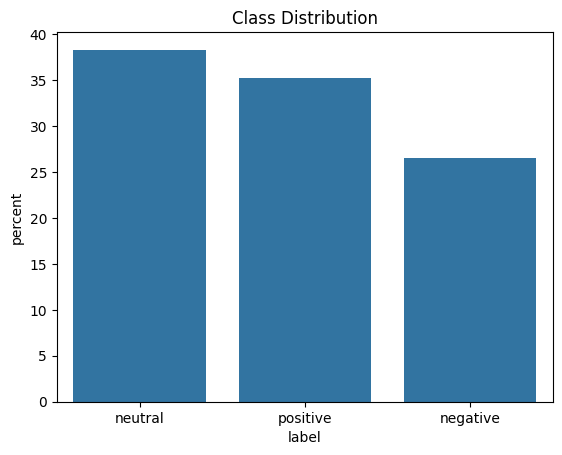

In [6]:
sns.countplot(data=df_samples, x="label", stat="percent")
plt.title("Class Distribution")
plt.show()

The dataset shows a relatively balanced distribution across sentiment classes.

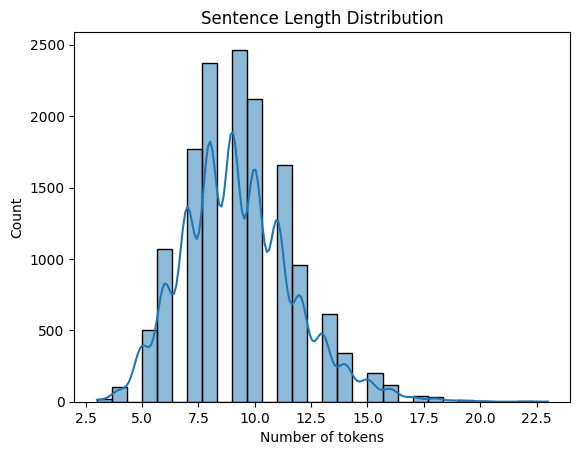

In [8]:
df_samples["length"] = df_samples["headline"].apply(lambda x: len(x.split()))

sns.histplot(df_samples["length"], bins=30, kde=True)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of tokens")
plt.show()

Headlines are short (≈10 words), making context sparse and increasing reliance on key sentiment words.

In [9]:
def tokenize(text):
    # keeps TARGET and OTHER, removes punctuation
    return re.findall(r"\b\w+\b", str(text))

tokens = []

for text in df_samples["headline"]:
    tokens.extend(tokenize(text))

counter = Counter(tokens)
vocab = set(tokens)

print("Vocab size:", len(vocab))
print(counter.most_common(20))

Vocab size: 8699
[('TARGET', 14309), ('OTHER', 9309), ('to', 3834), ('on', 3297), ('in', 2825), ('Rs', 1726), ('of', 1521), ('for', 1446), ('as', 1229), ('crore', 1053), ('up', 1008), ('at', 978), ('a', 926), ('net', 829), ('the', 701), ('and', 680), ('over', 646), ('s', 614), ('profit', 601), ('with', 527)]


In [10]:
df_samples["target_pos"] = df_samples["headline"].apply(target_position)

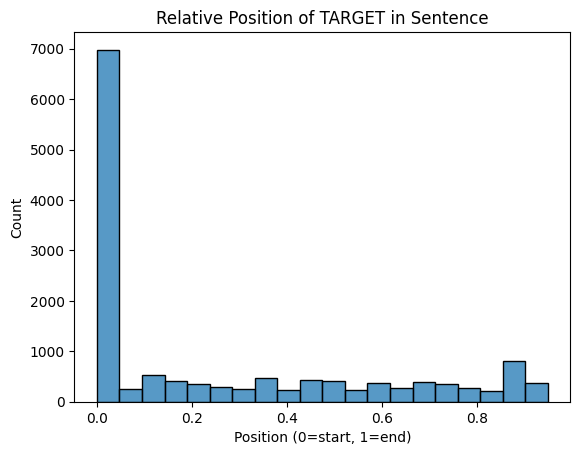

In [11]:
sns.histplot(df_samples["target_pos"].dropna(), bins=20)
plt.title("Relative Position of TARGET in Sentence")
plt.xlabel("Position (0=start, 1=end)")
plt.show()

TARGET appears mainly at the start of the sentence. But, it does appear at all positions, meaning models must learn sentiment patterns independent of position.

In [12]:
df_samples["n_other"] = df_samples["headline"].apply(other_numbers)

In [15]:
df_samples.value_counts('n_other')

n_other
0    8081
1    4332
2    1409
3     399
4     159
5      18
6       7
Name: count, dtype: int64

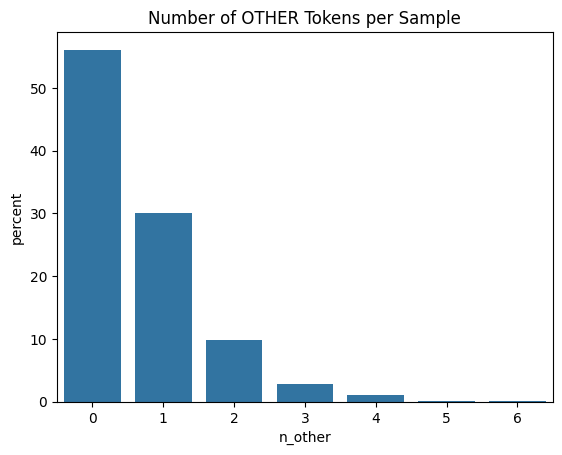

In [13]:
sns.countplot(data=df_samples, x="n_other", stat="percent")
plt.title("Number of OTHER Tokens per Sample")
plt.show()

This plot si to be viewd with caution as headlines are over counted in samples when multiple entities are present.

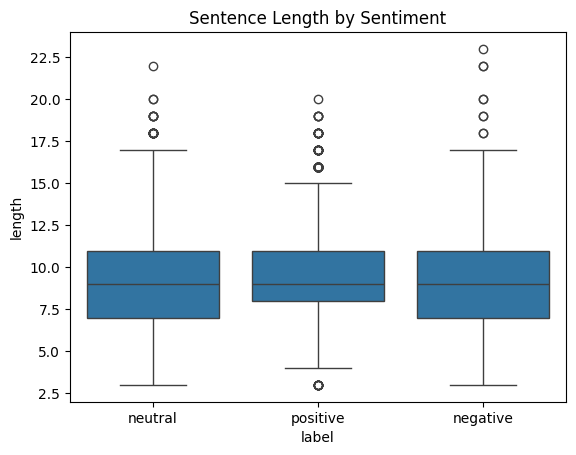

In [19]:
sns.boxplot(data=df_samples, x="label", y="length")
plt.title("Sentence Length by Sentiment")
plt.show()

All sentiments have comparable sentence means on average. However, positive sentiment show less variability.

In [20]:
custom_stopwords = get_custom_stopwords()

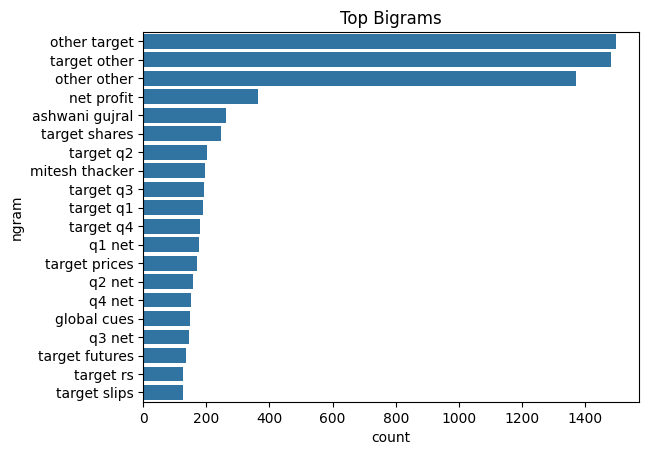

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20, stop_words=list(custom_stopwords))
X = vectorizer.fit_transform(df_samples["headline"])

ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

df_ngrams = pd.DataFrame({"ngram": ngrams, "count": counts})
df_ngrams = df_ngrams.sort_values(by="count", ascending=False)

sns.barplot(data=df_ngrams, x="count", y="ngram")
plt.title("Top Bigrams")
plt.show()

TF-IDF vectorization transforms text into a numerical representation by assigning a weight to each word in a sentence. A word receives a high weight if it is frequent within the sentence (term frequency) and relatively rare across the dataset (inverse document frequency).

To analyze the importance of words, we compute the average TF-IDF score of each word across sentences belonging to a given sentiment class. We then visualize the words with the highest average scores for each class.

For example, if a word such as “rises” has a high average TF-IDF score in the positive class, this indicates that it appears frequently in positive sentences while being less common in the overall dataset, making it a strong lexical signal associated with positive sentiment.

In [22]:
X, tfidf, feature_names = build_tfidf(df_samples["headline"], 
                                      max_features=10000, 
                                      stop_words=custom_stopwords)

In [23]:
df_scores = get_global_top_tfidf_words(X, feature_names, top_n=10)
df_scores

,word,score
0,other,0.082550
1,target,0.067337
2,rs,0.024056
3,crore,0.017096
4,net,0.016239
5,profit,0.012019
6,shares,0.011056
7,cent,0.009311
8,stocks,0.009264
9,high,0.009003


In [24]:
labels = df_samples["label"]
top_words_df = get_top_words_all_classes(X, labels, feature_names, top_n=10)

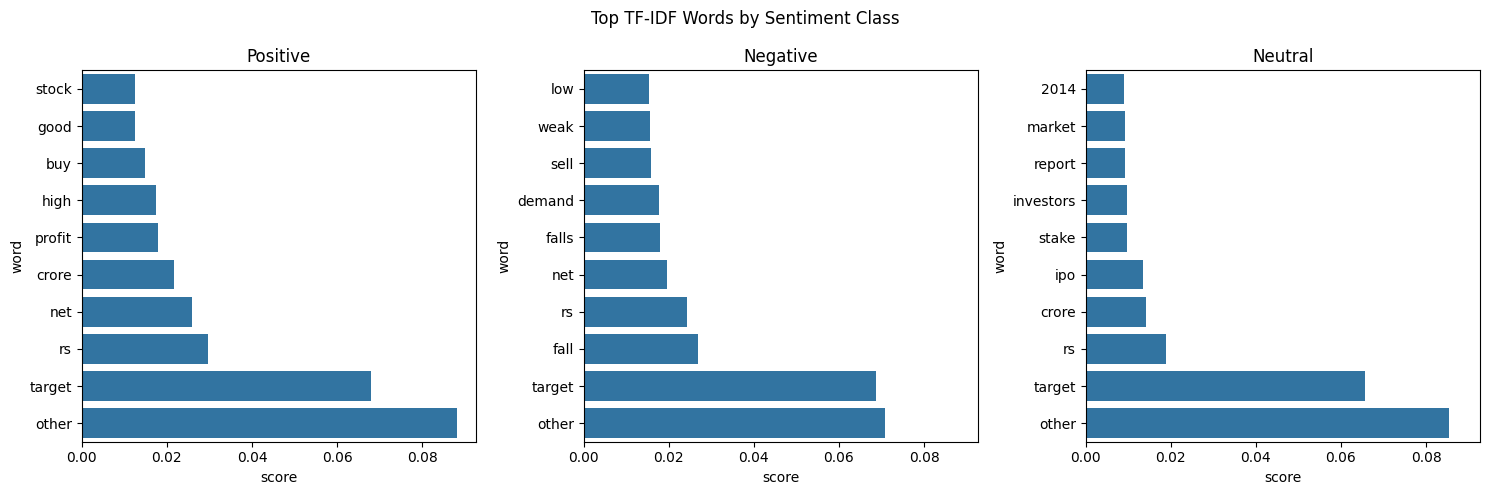

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

for ax, label in zip(axes, ["positive", "negative", "neutral"]):
    subset = top_words_df[top_words_df["label"] == label]
    subset = subset.sort_values("score", ascending=True)
    
    sns.barplot(data=subset, x="score", y="word", ax=ax)
    ax.set_title(label.capitalize())

plt.suptitle("Top TF-IDF Words by Sentiment Class")
plt.tight_layout()
plt.show()

The TF-IDF analysis per class reveals that positive and negative sentiments are driven by distinct directional tokens, like profit or high for positive, fall, low for negative, whereas neutral samples are characterized by general financial terminology, like ipo, investors or trading. However, tokens like net, rs or crore are present for diffrent sentiments.

In [26]:
X_lsa, svd = fit_lsa(X, n_components=50)
df_topics = build_topic_dataframe(X_lsa, labels)

In [27]:
terms = tfidf.get_feature_names_out()

for i, comp in enumerate(svd.components_[:10]):
    top_idx = np.argsort(comp)[-10:]
    print(f"Topic {i}:")
    print([terms[j] for j in top_idx])

Topic 0:
['stake', 'net', 'fall', 'buy', 'stocks', 'shares', 'crore', 'rs', 'target', 'other']
Topic 1:
['q4', 'q3', 'cr', 'q2', 'target', 'q1', 'profit', 'crore', 'net', 'rs']
Topic 2:
['cent', 'shares', 'prices', 'weak', 'futures', 'fall', 'cues', 'target', 'global', 'demand']
Topic 3:
['rs', 'good', 'market', 'mitesh', 'thacker', 'sell', 'buy', 'target', 'gujral', 'ashwani']
Topic 4:
['buys', 'year', 'hit', 'stake', 'month', '52', 'hits', 'week', 'high', 'shares']
Topic 5:
['crore', 'ipo', 'buy', 'lakh', 'fall', 'buys', 'sell', 'rs', 'stake', 'shares']
Topic 6:
['results', 'earnings', 'q1', 'net', 'fall', 'profit', 'ashwani', 'gujral', 'cent', 'shares']
Topic 7:
['results', 'long', 'profit', 'target', 'term', 'stock', 'mohoni', 'good', 'deepak', 'buy']
Topic 8:
['gains', 'stock', 'profit', 'shares', 'good', 'mohoni', 'deepak', 'buy', 'cues', 'global']
Topic 9:
['hits', 'crore', 'high', 'cent', 'mohoni', 'good', 'deepak', 'stake', 'demand', 'buy']


<Axes: >

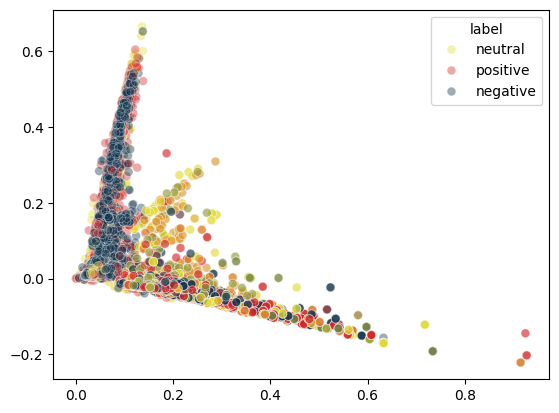

In [28]:
palette = {
    "neutral": "#e2dc36",  # green
    "positive": "#d62728",  # red
    "negative":  "#0e314a"   # blue
}

sns.scatterplot(
    x=X_lsa[:,0],
    y=X_lsa[:,1],
    hue=df_samples["label"],
    alpha=0.4, 
    palette = palette, 
    s = 40
)

LSA captures partial sentiment signal, but not enough for clear separation. As we left branch is dominated by negative sentiment while centered region of the V shape is neutral and right branch is mixed.

In [29]:
df_mean = df_topics.groupby("label").mean()
df_mean

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,...,topic_40,topic_41,topic_42,topic_43,topic_44,topic_45,topic_46,topic_47,topic_48,topic_49
label,,,,,,,,,,,,,,,,,,,,,
negative,0.112845,0.041716,0.050248,0.003966,0.001633,-0.000351,-0.000105,0.004743,-0.005395,-0.007638,...,-0.003598,0.000933,0.003344,0.005363,0.002203,0.003320,-0.001842,0.002902,-0.004667,0.000702
neutral,0.117034,0.016525,0.011174,0.018459,0.009150,0.005211,-0.013947,0.009173,-0.002733,-0.016386,...,-0.000989,-0.006929,-0.008057,-0.001625,-0.001980,0.002052,0.000943,-0.001145,-0.001456,-0.001505
positive,0.130454,0.046902,0.021372,0.013318,0.013422,-0.011271,-0.004026,0.014109,0.005710,0.007191,...,0.003190,0.000030,0.002592,-0.001735,0.001702,-0.006764,0.001178,-0.000663,0.003403,-0.000771


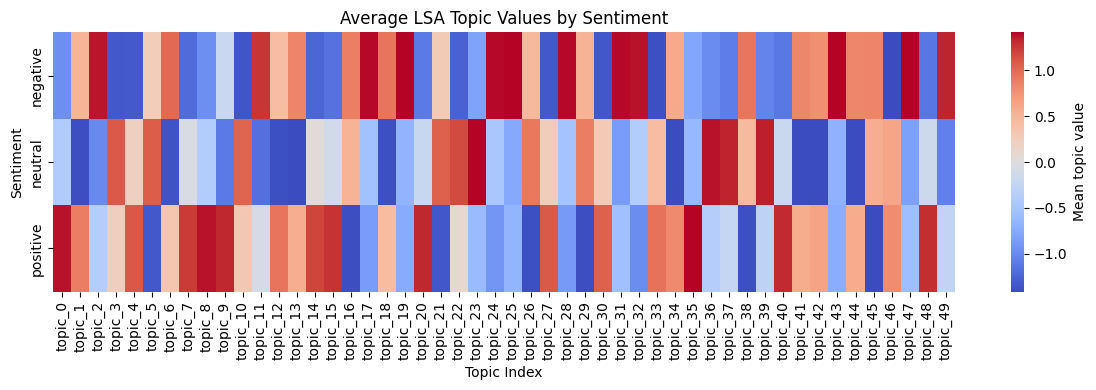

In [25]:
df_scaled = standardize_topic_means(df_mean)

plt.figure(figsize=(12, 4))

sns.heatmap(
    df_scaled,
    cmap="coolwarm",
    center=0,        
    annot=False,     
    cbar_kws={"label": "Mean topic value"}
)

plt.title("Average LSA Topic Values by Sentiment")
plt.xlabel("Topic Index")
plt.ylabel("Sentiment")

plt.tight_layout()
plt.show()

LSA learns latent dimensions that partially align with sentiment polarity, even though it is completely unsupervised. As we've seen in the previous plot, first dimension seperates negative and positive sentiment while second dimension does not. We pick a high contrast topic like topic 14 with a clear progression from negative to positve for more details.

In [33]:
pos_side, neg_side = get_topic_terms(svd, 
                                     feature_names, 
                                     topic_idx = 14, 
                                     top_n=10)

In [34]:
print("Topic 14 - Positive side:")
print(pos_side)

print("\nTopic 14 - Negative side:")
print(neg_side)

Topic 14 - Positive side:
         word    weight      side
0      stocks  0.645714  positive
1       focus  0.289333  positive
2          cr  0.288007  positive
3  rangebound  0.200687  positive
4          pc  0.137122  positive
5       stake  0.113722  positive
6        like  0.088257  positive
7      profit  0.087978  positive
8          10  0.083931  positive
9       stock  0.075244  positive

Topic 14 - Negative side:
      word    weight      side
0    crore -0.204057  negative
1     fall -0.122815  negative
2     week -0.120434  negative
3   deepak -0.119458  negative
4       q1 -0.109192  negative
5   mohoni -0.107961  negative
6     term -0.092167  negative
7  thacker -0.080890  negative
8   mitesh -0.080890  negative
9  results -0.080751  negative


# Modeling : Classification task

## Training and testing 

In [58]:
df_model = prepare_labels(
    df_samples,
    text_col="headline",     
    label_col="label"
)

df_model.head()

,text,label,n_other,label_id
0,TARGET to issue 6.4 crore warrants to promoters,neutral,0,1
1,TARGET Q2 net loss at Rs 10.4 crore,neutral,0,1
2,"TARGET can deliver more, stay put: Experts",positive,0,2
3,TARGET now turn into market darlings,positive,0,2
4,"TARGET seeing patience, if not conviction: Pra...",neutral,0,1


In [60]:
from src.error_analysis import *

In [59]:
train_df, val_df, test_df = random_split(df_model)

X_train = train_df["text"]
y_train = train_df["label_id"]

X_val = val_df["text"]
y_val = val_df["label_id"]

X_test = test_df["text"]
y_test = test_df["label_id"]

In [63]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

model_lr = train_logistic_regression(
    X_train_tfidf,
    y_train,
    class_weight="balanced"
)


y_pred, proba = predict_classical(model_lr, X_test_tfidf)

errors_mixed_lr = build_error_df(
    test_df=test_df,
    y_pred=y_pred,
    proba=proba
)

res_lr = evaluate_predictions(
    y_test,
    y_pred,
    target_names=["negative", "neutral", "positive"]
)

c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.792852185981957
Macro F1: 0.7931448495748352
Weighted F1: 0.7927912194772735
              precision    recall  f1-score   support

    negative       0.80      0.79      0.79       763
     neutral       0.78      0.78      0.78      1104
    positive       0.81      0.82      0.81      1015

    accuracy                           0.79      2882
   macro avg       0.79      0.79      0.79      2882
weighted avg       0.79      0.79      0.79      2882



In [66]:
svd = TruncatedSVD(n_components=100)

X_train_lsa = svd.fit_transform(X_train_tfidf)
X_val_lsa = svd.transform(X_val_tfidf)
X_test_lsa = svd.transform(X_test_tfidf)

model_lsa_lr = train_logistic_regression(
    X_train_lsa,
    y_train,
    class_weight="balanced"
)

y_pred, proba = predict_classical(model_lsa_lr, X_test_lsa)

errors_mixed_lsa_lr= build_error_df(
    test_df=test_df,
    y_pred=y_pred,
    proba=proba
)

res_lsa_lr = evaluate_predictions(
    y_test,
    y_pred,
    target_names=["negative", "neutral", "positive"]
)

c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.6877168632893824
Macro F1: 0.6851090782789265
Weighted F1: 0.6874966750065002
              precision    recall  f1-score   support

    negative       0.68      0.65      0.66       763
     neutral       0.69      0.70      0.70      1104
    positive       0.69      0.70      0.70      1015

    accuracy                           0.69      2882
   macro avg       0.69      0.68      0.69      2882
weighted avg       0.69      0.69      0.69      2882



In [67]:
model_xgb = train_xgboost(
    X_train_lsa,
    y_train
)

y_pred, proba = predict_classical(model_xgb, X_test_lsa)


errors_mixed_xgb= build_error_df(
    test_df=test_df,
    y_pred=y_pred,
    proba=proba
)

res_xgb = evaluate_predictions(
    y_test,
    y_pred,
    target_names=["negative", "neutral", "positive"]
)

Accuracy: 0.6991672449687717
Macro F1: 0.6926900345585466
Weighted F1: 0.6972589199478926
              precision    recall  f1-score   support

    negative       0.74      0.58      0.65       763
     neutral       0.67      0.77      0.72      1104
    positive       0.71      0.71      0.71      1015

    accuracy                           0.70      2882
   macro avg       0.71      0.69      0.69      2882
weighted avg       0.70      0.70      0.70      2882



In [69]:
df_model['n_entities'] = df_model['n_other'] + 1

In [72]:
train_df_e, test_df_e = entity_split(
    df_model,
    entity_count_col="n_entities",
    train_on="single",
    test_on="multiple"
)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train = tfidf.fit_transform(train_df_e["text"])
y_train = train_df_e["label_id"]

X_test = tfidf.transform(test_df_e["text"])
y_test = test_df_e["label_id"]

model = train_logistic_regression(X_train, y_train, class_weight="balanced")

y_pred, proba= predict_classical(model, X_test)

errors_transf_lr= build_error_df(
    test_df=test_df_e,
    y_pred=y_pred,
    proba=proba
)

res1 = evaluate_predictions(
    y_test,
    y_pred,
    target_names=["negative", "neutral", "positive"]
)

c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.6159076533839343
Macro F1: 0.6019491130018643
Weighted F1: 0.6089068925320734
              precision    recall  f1-score   support

    negative       0.71      0.49      0.58      1416
     neutral       0.56      0.79      0.65      2710
    positive       0.69      0.49      0.57      2198

    accuracy                           0.62      6324
   macro avg       0.66      0.59      0.60      6324
weighted avg       0.64      0.62      0.61      6324



In [74]:
train_df_e, test_df_e = entity_split(
    df_model,
    entity_count_col="n_entities",
    train_on="multiple",
    test_on="single"
)


tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(train_df_e["text"])
y_train = train_df_e["label_id"]

X_test = tfidf.transform(test_df_e["text"])
y_test = test_df_e["label_id"]

svd = TruncatedSVD(n_components=100)

X_train_lsa = svd.fit_transform(X_train)
X_test_lsa = svd.transform(X_test)

model_lsa_lr = train_logistic_regression(
    X_train_lsa,
    y_train,
    class_weight="balanced"
)

y_pred, proba = predict_classical(model_lsa_lr, X_test_lsa)

errors_transf_lsa_lr= build_error_df(
    test_df=test_df_e,
    y_pred=y_pred,
    proba=proba
)

res2 = evaluate_predictions(
    y_test,
    y_pred,
    target_names=["negative", "neutral", "positive"]
)

Accuracy: 0.566761539413439
Macro F1: 0.5582299099265521
Weighted F1: 0.5574671375081472
              precision    recall  f1-score   support

    negative       0.69      0.48      0.56      2398
     neutral       0.47      0.82      0.60      2807
    positive       0.73      0.39      0.51      2876

    accuracy                           0.57      8081
   macro avg       0.63      0.56      0.56      8081
weighted avg       0.63      0.57      0.56      8081



c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [76]:
train_df_e, test_df_e = entity_split(
    df_model,
    entity_count_col="n_entities",
    train_on="multiple",
    test_on="single"
)


model_xgb = train_xgboost(
    X_train_lsa,
    y_train
)

y_pred, proba = predict_classical(model_xgb, X_test_lsa)


errors_transf_xgb= build_error_df(
    test_df=test_df_e,
    y_pred=y_pred,
    proba=proba
)


res3 = evaluate_predictions(
    y_test,
    y_pred,
    target_names=["negative", "neutral", "positive"]
)

Accuracy: 0.5286474446231902
Macro F1: 0.5037973479116963
Weighted F1: 0.5040494859934361
              precision    recall  f1-score   support

    negative       0.83      0.35      0.49      2398
     neutral       0.44      0.91      0.59      2807
    positive       0.72      0.31      0.43      2876

    accuracy                           0.53      8081
   macro avg       0.66      0.52      0.50      8081
weighted avg       0.65      0.53      0.50      8081



In [ ]:
# trainer, tokenizer = train_bert_classifier(
#     train_df,
#     val_df,
#     model_name="ProsusAI/finbert",
#     num_train_epochs=3
# )

Map: 100%|██████████| 10083/10083 [00:00<00:00, 23375.13 examples/s]
c:\Users\inesr\Downloads\nlp project\src\models.py:247: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.423100,0.430952,0.843750,0.843482,0.844251
2,0.287800,0.401221,0.875000,0.874222,0.874816
3,0.219000,0.446863,0.875000,0.874579,0.874944


c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [78]:
model_dir = "./bert_results/checkpoint-1893"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_dir)

# Load model
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    compute_metrics=compute_hf_metrics
)

C:\Users\inesr\AppData\Local\Temp\ipykernel_17720\1761863004.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [81]:
y_true, y_pred, proba = predict_bert(
    trainer,
    tokenizer,
    test_df
)


errors_mixed_bret= build_error_df(
    test_df=test_df,
    y_pred=y_pred,
    proba=proba
)

res_bert = evaluate_predictions(
    y_true,
    y_pred,
    target_names=["negative", "neutral", "positive"])

Map: 100%|██████████| 2882/2882 [00:00<00:00, 27028.14 examples/s]
c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.8809854267869535
Macro F1: 0.8819352381532459
Weighted F1: 0.8808285521649061
              precision    recall  f1-score   support

    negative       0.88      0.90      0.89       763
     neutral       0.89      0.85      0.87      1104
    positive       0.88      0.90      0.89      1015

    accuracy                           0.88      2882
   macro avg       0.88      0.88      0.88      2882
weighted avg       0.88      0.88      0.88      2882



In [51]:
train_df_e, test_df_e = entity_split(
    df_model,
    entity_count_col="n_entities",
    train_on="single",
    test_on="multiple"
)

train_df_e, val_df_e, _ = random_split(train_df_e)

In [ ]:
# trainer, tokenizer = train_bert_classifier(
#     train_df_e,
#     val_df_e,
#     output_dir = "./bert_results_single",
#     num_train_epochs=3
# )

# y_true, y_pred, _ = predict_bert(trainer, tokenizer, test_df_e)

# evaluate_predictions(
#     y_true,
#     y_pred,
#     target_names=["negative", "neutral", "positive"]
# )

Map: 100%|██████████| 5656/5656 [00:00<00:00, 37556.75 examples/s]
c:\Users\inesr\Downloads\nlp project\src\models.py:247: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.401400,0.439017,0.844059,0.843760,0.843131
2,0.268800,0.474917,0.860149,0.861265,0.860533
3,0.187300,0.506734,0.863861,0.864717,0.863598


c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Map: 100%|██████████| 6324/6324 [00:00<00:00, 43161.86 examples/s]
c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.7365591397849462
Macro F1: 0.7364580418806298
Weighted F1: 0.7365677578899422
              precision    recall  f1-score   support

    negative       0.72      0.75      0.74      1416
     neutral       0.72      0.75      0.74      2710
    positive       0.76      0.71      0.74      2198

    accuracy                           0.74      6324
   macro avg       0.74      0.74      0.74      6324
weighted avg       0.74      0.74      0.74      6324



{'accuracy': 0.7365591397849462,
 'f1_macro': 0.7364580418806298,
 'f1_weighted': 0.7365677578899422,
 'classification_report': {'negative': {'precision': 0.7238550922761449,
   'recall': 0.7478813559322034,
   'f1-score': 0.7356721083709621,
   'support': 1416.0},
  'neutral': {'precision': 0.7249017506252233,
   'recall': 0.7487084870848708,
   'f1-score': 0.7366128153929933,
   'support': 2710.0},
  'positive': {'precision': 0.7613967022308439,
   'recall': 0.7142857142857143,
   'f1-score': 0.7370892018779343,
   'support': 2198.0},
  'accuracy': 0.7365591397849462,
  'macro avg': {'precision': 0.7367178483774041,
   'recall': 0.7369585191009295,
   'f1-score': 0.7364580418806298,
   'support': 6324.0},
  'weighted avg': {'precision': 0.7373517562240308,
   'recall': 0.7365591397849462,
   'f1-score': 0.7365677578899422,
   'support': 6324.0}},
 'confusion_matrix': array([[1059,  247,  110],
        [ 299, 2029,  382],
        [ 105,  523, 1570]])}

In [82]:
model_dir = "./bert_results_single/checkpoint-1062"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_dir)

# Load model
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    compute_metrics=compute_hf_metrics
)

C:\Users\inesr\AppData\Local\Temp\ipykernel_17720\2505790842.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [83]:
y_true, y_pred, proba = predict_bert(
    trainer,
    tokenizer,
    test_df
)


errors_transf_bret= build_error_df(
    test_df=test_df,
    y_pred=y_pred,
    proba=proba
)


res4 = evaluate_predictions(
    y_true,
    y_pred,
    target_names=["negative", "neutral", "positive"])

Map: 100%|██████████| 2882/2882 [00:00<00:00, 33223.17 examples/s]
c:\Users\inesr\Downloads\nlp project\nlpml\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.8514920194309508
Macro F1: 0.8527317656407778
Weighted F1: 0.851530814086005
              precision    recall  f1-score   support

    negative       0.85      0.87      0.86       763
     neutral       0.83      0.84      0.84      1104
    positive       0.87      0.85      0.86      1015

    accuracy                           0.85      2882
   macro avg       0.85      0.85      0.85      2882
weighted avg       0.85      0.85      0.85      2882



Single and multiple entity mixed

In [94]:
results = pd.DataFrame([
    {"model": "TF-IDF + LR", **res_lr},
    {"model": "LSA + LR", **res_lsa_lr},
    {"model": "LSA + XGB", **res_xgb},
    {"model": "finBERT", **res_bert},
])

results[["model", "accuracy", "f1_macro", "f1_weighted"]].sort_values(
    "f1_macro",
    ascending=False
)

,model,accuracy,f1_macro,f1_weighted
3,finBERT,0.880985,0.881935,0.880829
0,TF-IDF + LR,0.792852,0.793145,0.792791
2,LSA + XGB,0.699167,0.692690,0.697259
1,LSA + LR,0.687717,0.685109,0.687497


Train on single, test on multiple.

In [95]:
results = pd.DataFrame([
    {"model": "TF-IDF + LR", **res1},
    {"model": "LSA + LR", **res2},
    {"model": "LSA + XGB", **res3},
    {"model": "finBERT", **res4},
])

results[["model", "accuracy", "f1_macro", "f1_weighted"]].sort_values(
    "f1_macro",
    ascending=False
)

,model,accuracy,f1_macro,f1_weighted
3,finBERT,0.851492,0.852732,0.851531
0,TF-IDF + LR,0.615908,0.601949,0.608907
1,LSA + LR,0.566762,0.558230,0.557467
2,LSA + XGB,0.528647,0.503797,0.504049


## Error analysis

Standard train test

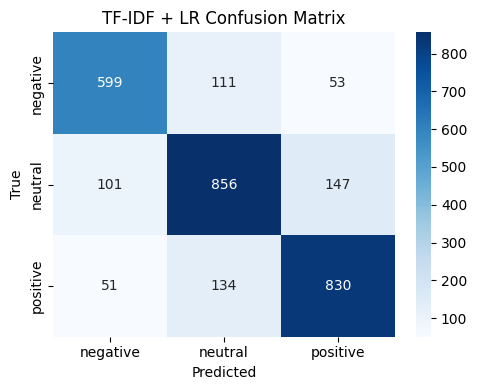

In [84]:
plot_confusion(errors_mixed_lr, "TF-IDF + LR Confusion Matrix")

In [87]:
get_errors(errors_mixed_lr, n=5)

,text,true_label,pred_label,confidence,proba_negative,proba_neutral,proba_positive
1887,OTHER 'A+' to TARGET perpetual bonds,positive,neutral,0.938638,0.019951,0.938638,0.041411
2066,TARGET increases stake in OTHER to 9%,positive,neutral,0.924579,0.017656,0.924579,0.057765
1182,TARGET narrows down net loss to Rs 156.36 cror...,positive,negative,0.919298,0.919298,0.043870,0.036832
1960,TARGET mis-stated facts in OTHER filings,negative,neutral,0.906462,0.036263,0.906462,0.057275
1461,"TARGET snaps two-day fall as exporters, corpor...",positive,negative,0.904592,0.904592,0.064646,0.030762


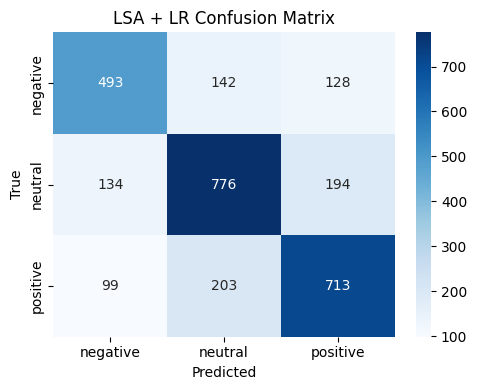

In [ ]:
plot_confusion(errors_mixed_lsa_lr, "LSA + LR Confusion Matrix")

In [89]:
get_errors(errors_mixed_lsa_lr, n=5)

,text,true_label,pred_label,confidence,proba_negative,proba_neutral,proba_positive
1181,OTHER continues to fall on weak demand; TARGET...,positive,negative,0.974279,0.974279,0.019023,0.006698
2799,"TARGET hits 19-mth low as supply overwhelms, O...",positive,negative,0.964850,0.964850,0.019560,0.015591
1182,TARGET narrows down net loss to Rs 156.36 cror...,positive,negative,0.953790,0.953790,0.024775,0.021435
1887,OTHER 'A+' to TARGET perpetual bonds,positive,neutral,0.944472,0.024381,0.944472,0.031147
509,Synergy with OTHER to propel TARGET,positive,neutral,0.924960,0.024291,0.924960,0.050749


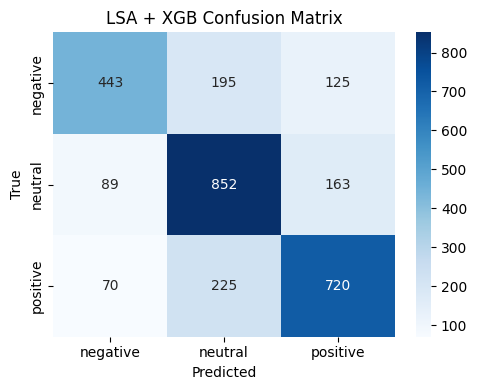

In [90]:
plot_confusion(errors_mixed_xgb, "LSA + XGB Confusion Matrix")

In [91]:
get_errors(errors_mixed_xgb, n=5)

,text,true_label,pred_label,confidence,proba_negative,proba_neutral,proba_positive
1182,TARGET narrows down net loss to Rs 156.36 cror...,positive,negative,0.972049,0.972049,0.012256,0.015695
1181,OTHER continues to fall on weak demand; TARGET...,positive,negative,0.957948,0.957948,0.029331,0.012722
2109,PSU banks join party; TARGET hits all-time high,neutral,positive,0.942453,0.029766,0.027781,0.942453
2202,"OTHER, OTHER and OTHER are good bets now: Phan...",neutral,positive,0.937279,0.016118,0.046602,0.937279
2799,"TARGET hits 19-mth low as supply overwhelms, O...",positive,negative,0.934797,0.934797,0.031229,0.033974


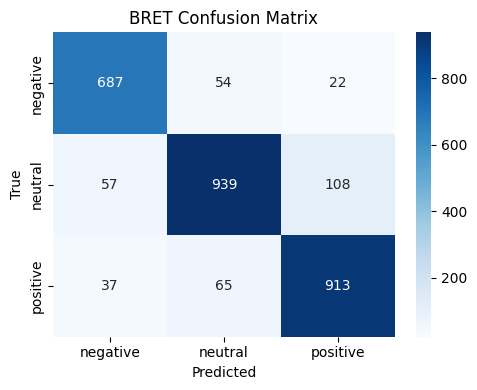

In [92]:
plot_confusion(errors_mixed_bret, "BRET Confusion Matrix")

In [93]:
get_errors(errors_mixed_bret, n=5)

,text,true_label,pred_label,confidence,proba_negative,proba_neutral,proba_positive
177,"TARGET rally on OTHER price hike, but end day ...",neutral,positive,0.995710,0.002566,0.001725,0.995710
2109,PSU banks join party; TARGET hits all-time high,neutral,positive,0.995661,0.002299,0.002040,0.995661
2607,TARGET futures gain 0.79% on upsurge in demand,negative,positive,0.995505,0.002933,0.001561,0.995505
1890,Britain TARGET regains traction as OTHER steadies,neutral,positive,0.995425,0.001844,0.002731,0.995425
851,TARGET posts Q3 net loss of Rs 22.25 cr; stock up,negative,positive,0.994506,0.004167,0.001327,0.994506


In [103]:
df_comp = compare_errors(errors_mixed_bret, errors_mixed_lr, name_a="BRET", name_b="TF-IDF")

In [120]:
df_comp.loc[df_comp['case'] == 'Only BRET wrong'].head()

,text,true_label,pred_BRET,error_BRET,pred_TF-IDF,error_TF-IDF,case
5,"OTHER makes $1.9 bn second open offer, TARGET ...",positive,neutral,True,positive,False,Only BRET wrong
23,Would not take a position on the TARGET: Deepa...,negative,neutral,True,negative,False,Only BRET wrong
51,OTHER end mixed as decline in TARGET shares we...,negative,neutral,True,negative,False,Only BRET wrong
78,"MMTC-PAMP OTHER, TARGET coins stock sold out o...",positive,negative,True,positive,False,Only BRET wrong
88,TARGET is the sector to be in: Prakash Diwan,positive,neutral,True,positive,False,Only BRET wrong


Train on single, test on multiple

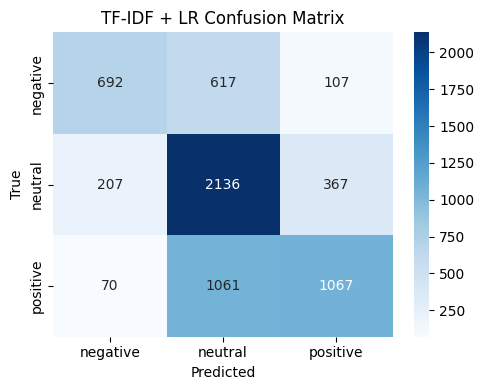

In [96]:
plot_confusion(errors_transf_lr, "TF-IDF + LR Confusion Matrix")

In [123]:
get_errors(errors_transf_lr, n=20)

,text,true_label,pred_label,confidence,proba_negative,proba_neutral,proba_positive
4382,TARGET indulged in IPO irregularities: OTHER,negative,neutral,0.976236,0.009284,0.976236,0.014480
2744,TARGET rally stalls; OTHER eyes record high,neutral,positive,0.968292,0.008041,0.023667,0.968292
5013,"OTHER hits 19-mth low as supply overwhelms, TA...",positive,negative,0.966324,0.966324,0.021132,0.012544
978,"OTHER rallies over 4%, hits fresh 52-week high...",neutral,positive,0.955697,0.021605,0.022698,0.955697
5012,"TARGET hits 19-mth low as supply overwhelms, O...",positive,negative,0.954162,0.954162,0.025112,0.020726
3960,OTHER rallies on strategic tie-up with TARGET,neutral,positive,0.946007,0.011972,0.042021,0.946007
4355,OTHER underperforms flat TARGETs,negative,neutral,0.945142,0.028971,0.945142,0.025887
6182,OTHER opens flat as TARGET offsets OTHER,positive,neutral,0.940178,0.031482,0.940178,0.028340
5795,OTHER downgrades TARGET to neutral; prefers OTHER,negative,neutral,0.938415,0.023613,0.938415,0.037973
4598,"OTHER ends 4% lower on weak Q4 outlook, TARGET...",neutral,negative,0.936833,0.936833,0.032045,0.031121


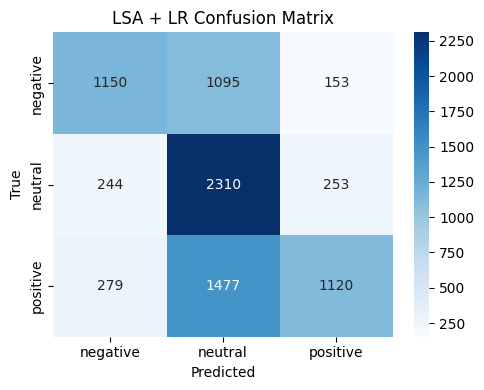

In [124]:
plot_confusion(errors_transf_lsa_lr, "LSA + LR Confusion Matrix")

In [125]:
get_errors(errors_transf_lsa_lr, n=5)

,text,true_label,pred_label,confidence,proba_negative,proba_neutral,proba_positive
5101,"Shilpa Shetty, Raj Kundra snap up defunct TARGET",neutral,positive,0.926297,0.021947,0.051756,0.926297
3462,NMCE asks members dealing with TARGET defaulte...,negative,neutral,0.894241,0.055457,0.894241,0.050303
1889,TARGET soar as lower oil prices bring down fares,positive,negative,0.884419,0.884419,0.059332,0.056249
616,"TARGET snaps two-day fall as exporters, corpor...",positive,negative,0.871150,0.871150,0.098664,0.030186
7986,Tariff value of TARGET increased to $521/10 gm...,negative,neutral,0.859518,0.057445,0.859518,0.083036


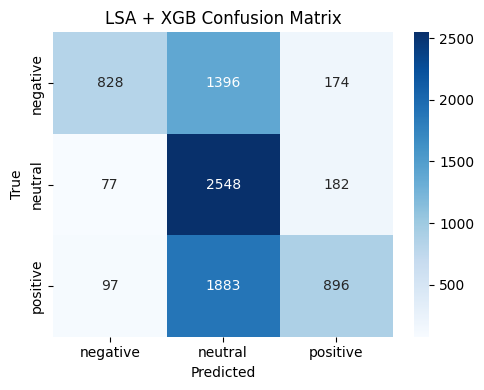

In [126]:
plot_confusion(errors_transf_xgb, "LSA + XGB Confusion Matrix")

In [127]:
get_errors(errors_transf_xgb, n=5)

,text,true_label,pred_label,confidence,proba_negative,proba_neutral,proba_positive
1563,TARGET IPO oversubscribed,positive,neutral,0.955745,0.012387,0.955745,0.031869
1641,TARGET IPO fully subscribed,positive,neutral,0.955745,0.012387,0.955745,0.031869
7135,TARGET Q4 net loss at Rs 23.74 crore,negative,neutral,0.925294,0.014193,0.925294,0.060513
6543,"TARGET seeks OTHER's nod to raise upto Rs 1,00...",positive,neutral,0.923478,0.011549,0.923478,0.064973
7133,TARGET Q2 net loss at Rs 25.90 crore,negative,neutral,0.923120,0.013965,0.923120,0.062915


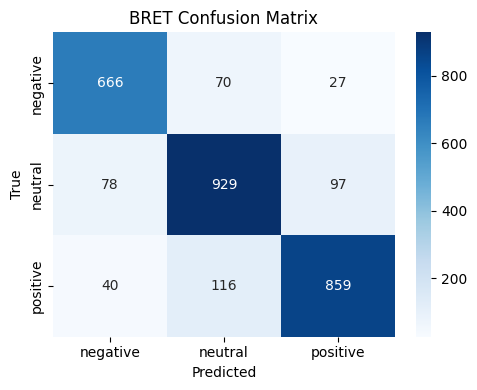

In [128]:
plot_confusion(errors_transf_bret, "BRET Confusion Matrix")

In [129]:
get_errors(errors_transf_bret, n=5)

,text,true_label,pred_label,confidence,proba_negative,proba_neutral,proba_positive
790,OTHER stock up 3% as TARGET buys shares; ups s...,neutral,positive,0.993783,0.003032,0.003185,0.993783
2776,OTHER to buy stake in TARGET; stock gains,neutral,positive,0.993296,0.003441,0.003263,0.993296
2696,OTHER rallies 7% as TARGET buys 15 lakh shares,neutral,positive,0.992998,0.002945,0.004057,0.992998
965,OTHER surges 12% as arm set to file draft pape...,neutral,positive,0.992895,0.003041,0.004064,0.992895
579,"OTHER gains 20% in 2 days; OTHER, TARGET picki...",neutral,positive,0.992891,0.002651,0.004458,0.992891


In [136]:
def prepare_class_error_plot(errors_dict):
    rows = []

    for model_name, df in errors_dict.items():
        agg = (
            df.groupby("true_label")["is_error"]
            .mean()
            .reset_index()
        )

        agg["model"] = model_name
        rows.append(agg)

    return pd.concat(rows)

In [137]:
errors_dict = {
    "TF-IDF + LR": errors_mixed_lr,
    "LSA + LR": errors_mixed_lsa_lr,
    "LSA + XGB": errors_mixed_xgb,
    "finBERT": errors_mixed_bret
}

plot_df = prepare_class_error_plot(errors_dict)

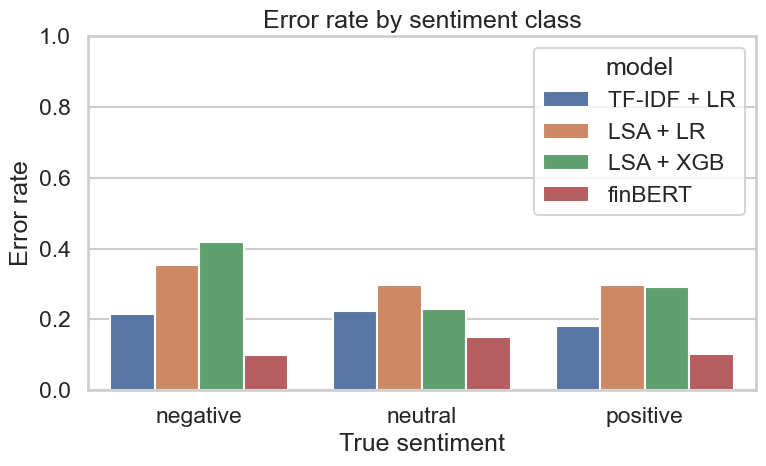

In [138]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    x="true_label",
    y="is_error",
    hue="model"
)

plt.title("Error rate by sentiment class")
plt.xlabel("True sentiment")
plt.ylabel("Error rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()